# Geospatial Time Series Analysis - Vegetation Dynamics Monitoring

## Context
Analyze long-term vegetation trends using MODIS NDVI time series with advanced statistical methods.

**Key Objectives**:
- Detect greening and browning trends using Mann-Kendall test
- Quantify trend magnitude with Sen's slope estimator
- Perform seasonal decomposition (trend, seasonal, residual)
- Analyze rainfall-NDVI correlation
- Identify drought events through anomaly detection
- Extract vegetation phenology metrics

**Study Area**: Sahel Region (West Africa)

**Applications**: Climate change monitoring, drought early warning, ecosystem health assessment

In [7]:
# Import Libraries
import ee
import geemap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

try:
    ee.Initialize()
except:
    ee.Authenticate()
    ee.Initialize()

plt.style.use('seaborn-v0_8-darkgrid')
print('✓ Libraries loaded successfully')

✓ Libraries loaded successfully


In [8]:
# Define Study Area - Sahel Region
sahel_region = ee.Geometry.Rectangle([-5, 12, 5, 16])

# Time period: 2010-2024 (14 years)
start_date = '2010-01-01'
end_date = '2024-01-01'

print(f'Study Area: {sahel_region.area().divide(1e6).getInfo():.2f} km²')
print(f'Analysis Period: {start_date} to {end_date}')

Study Area: 480790.31 km²
Analysis Period: 2010-01-01 to 2024-01-01


In [9]:
# Load MODIS NDVI Data (16-day composite)
print('Loading MODIS NDVI data...')

modis_ndvi = ee.ImageCollection('MODIS/061/MOD13A1') \
    .filterDate(start_date, end_date) \
    .filterBounds(sahel_region) \
    .select('NDVI')

# Scale factor: 0.0001
def scale_ndvi(image):
    return image.multiply(0.0001).copyProperties(image, ['system:time_start'])

ndvi_scaled = modis_ndvi.map(scale_ndvi)

print(f'NDVI images: {ndvi_scaled.size().getInfo()}')

# Load CHIRPS Precipitation Data
print('Loading CHIRPS precipitation data...')

chirps = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY') \
    .filterDate(start_date, end_date) \
    .filterBounds(sahel_region)

# Aggregate to monthly
def monthly_precip(year, month):
    start = ee.Date.fromYMD(year, month, 1)
    end = start.advance(1, 'month')
    return chirps.filterDate(start, end).sum() \
        .set('system:time_start', start.millis()) \
        .set('year', year).set('month', month)

years = ee.List.sequence(2010, 2023)
months = ee.List.sequence(1, 12)

monthly_rainfall = ee.ImageCollection.fromImages(
    years.map(lambda y: months.map(lambda m: monthly_precip(y, m))).flatten()
)

print(f'Monthly rainfall images: {monthly_rainfall.size().getInfo()}')
print('✓ All datasets loaded')

Loading MODIS NDVI data...
NDVI images: 322
Loading CHIRPS precipitation data...
Monthly rainfall images: 168
✓ All datasets loaded


In [10]:
# Extract Time Series for Sample Point
# Select a representative point in the Sahel
sample_point = ee.Geometry.Point([0.0, 14.0])

# Extract NDVI time series
def extract_ndvi(image):
    value = image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=sample_point.buffer(5000),
        scale=500
    ).get('NDVI')
    return ee.Feature(None, {
        'date': ee.Date(image.get('system:time_start')).format('YYYY-MM-dd'),
        'ndvi': value
    })

ndvi_ts = ndvi_scaled.map(extract_ndvi).getInfo()['features']
ndvi_df = pd.DataFrame([f['properties'] for f in ndvi_ts])
ndvi_df['date'] = pd.to_datetime(ndvi_df['date'])
ndvi_df = ndvi_df.dropna().sort_values('date').set_index('date')

# Extract rainfall time series (monthly)
def extract_rain(image):
    value = image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=sample_point.buffer(5000),
        scale=5000
    ).get('precipitation')
    return ee.Feature(None, {
        'date': ee.Date(image.get('system:time_start')).format('YYYY-MM'),
        'rainfall': value
    })

rain_ts = monthly_rainfall.map(extract_rain).getInfo()['features']
rain_df = pd.DataFrame([f['properties'] for f in rain_ts])
rain_df['date'] = pd.to_datetime(rain_df['date'])
rain_df = rain_df.dropna().sort_values('date').set_index('date')

print(f'NDVI observations: {len(ndvi_df)}')
print(f'Rainfall observations: {len(rain_df)}')
print('\nNDVI Statistics:')
print(ndvi_df.describe())

NDVI observations: 322
Rainfall observations: 168

NDVI Statistics:
             ndvi
count  322.000000
mean     0.254605
std      0.094249
min      0.133202
25%      0.185102
50%      0.214463
75%      0.304704
max      0.524713


In [11]:
# Mann-Kendall Trend Test
def mann_kendall_test(data):
    """Perform Mann-Kendall trend test."""
    n = len(data)
    s = 0
    
    for i in range(n-1):
        for j in range(i+1, n):
            s += np.sign(data[j] - data[i])
    
    # Variance
    var_s = n * (n - 1) * (2 * n + 5) / 18
    
    # Z-statistic
    if s > 0:
        z = (s - 1) / np.sqrt(var_s)
    elif s < 0:
        z = (s + 1) / np.sqrt(var_s)
    else:
        z = 0
    
    # P-value (two-tailed)
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    
    # Trend
    if p < 0.05:
        trend = 'Significant increasing' if z > 0 else 'Significant decreasing'
    else:
        trend = 'No significant trend'
    
    return {'z': z, 'p': p, 'trend': trend}

# Sen's Slope Estimator
def sens_slope(data, dates):
    """Calculate Sen's slope (median of all pairwise slopes)."""
    n = len(data)
    slopes = []
    
    for i in range(n-1):
        for j in range(i+1, n):
            delta_y = data[j] - data[i]
            delta_x = (dates[j] - dates[i]).days
            if delta_x != 0:
                slopes.append(delta_y / delta_x)
    
    return np.median(slopes) if slopes else 0

# Apply tests
print('\n=== Mann-Kendall Trend Analysis ===')
mk_result = mann_kendall_test(ndvi_df['ndvi'].values)
print(f'Z-statistic: {mk_result["z"]:.4f}')
print(f'P-value: {mk_result["p"]:.4f}')
print(f'Trend: {mk_result["trend"]}')

sens = sens_slope(ndvi_df['ndvi'].values, ndvi_df.index.to_series())
print(f"\nSen's Slope: {sens:.6f} NDVI/day")
print(f"Annual trend: {sens * 365:.4f} NDVI/year")


=== Mann-Kendall Trend Analysis ===
Z-statistic: 2.5413
P-value: 0.0110
Trend: Significant increasing

Sen's Slope: 0.000005 NDVI/day
Annual trend: 0.0017 NDVI/year


In [12]:
# Seasonal Decomposition
print('\n=== Seasonal Decomposition ===')

# Resample to monthly for cleaner decomposition
ndvi_monthly = ndvi_df.resample('M').mean()

# Decompose (additive model)
decomposition = seasonal_decompose(ndvi_monthly['ndvi'], model='additive', period=12)

trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

print('✓ Decomposition complete')
print(f'Trend range: {trend.min():.3f} to {trend.max():.3f}')
print(f'Seasonal amplitude: {seasonal.max() - seasonal.min():.3f}')


=== Seasonal Decomposition ===
✓ Decomposition complete
Trend range: 0.228 to 0.287
Seasonal amplitude: 0.269


In [14]:
print("ndvi_monthly:", ndvi_monthly.shape)
print("rain_df:", rain_df.shape)
print("merged:", merged.shape)
print(merged.head())


ndvi_monthly: (168, 1)
rain_df: (168, 1)
merged: (0, 2)
Empty DataFrame
Columns: [ndvi, rainfall]
Index: []


In [16]:
# make sure indices are datetime
ndvi_monthly.index = pd.to_datetime(ndvi_monthly.index)
rain_df.index = pd.to_datetime(rain_df.index)

# aggregate to monthly
ndvi_m = ndvi_monthly.resample('M').mean()[['ndvi']]
rain_m = rain_df.resample('M').sum()[['rainfall']]   # or .mean(), depending on your choice

# align and drop months with missing values
merged = ndvi_m.join(rain_m, how='inner').dropna()

print("Merged monthly shape:", merged.shape)
print(merged.head())


Merged monthly shape: (168, 2)
                ndvi      rainfall
date                              
2010-01-31  0.178456  5.544871e-08
2010-02-28  0.168731  0.000000e+00
2010-03-31  0.161488  1.000796e+00
2010-04-30  0.138263  3.434006e+00
2010-05-31  0.158750  1.977775e+01


In [17]:
print('\n=== NDVI-Rainfall Correlation ===')

if len(merged) >= 2:
    correlation, p_value = stats.pearsonr(merged['ndvi'], merged['rainfall'])
    print(f'Pearson correlation: {correlation:.3f}')
    print(f'P-value: {p_value:.4f}')

    if p_value < 0.05:
        print(f'✓ Significant {"positive" if correlation > 0 else "negative"} correlation')
    else:
        print('✗ No significant correlation')
else:
    print("Not enough overlapping monthly points to compute correlation.")



=== NDVI-Rainfall Correlation ===
Pearson correlation: 0.783
P-value: 0.0000
✓ Significant positive correlation


In [18]:
# Anomaly Detection - Drought Events
print('\n=== Drought Event Detection ===')

# Calculate z-scores
ndvi_monthly['z_score'] = (ndvi_monthly['ndvi'] - ndvi_monthly['ndvi'].mean()) / ndvi_monthly['ndvi'].std()

# Drought: z-score < -1.5
drought_events = ndvi_monthly[ndvi_monthly['z_score'] < -1.5]

print(f'Drought events detected: {len(drought_events)}')
if len(drought_events) > 0:
    print('\nDrought periods:')
    for date, row in drought_events.iterrows():
        print(f'  {date.strftime("%Y-%m")}: NDVI={row["ndvi"]:.3f}, z={row["z_score"]:.2f}')


=== Drought Event Detection ===
Drought events detected: 0


In [19]:
# Phenology Metrics
print('\n=== Vegetation Phenology Metrics ===')

# Calculate annual metrics
phenology = []
for year in range(2010, 2024):
    year_data = ndvi_df[ndvi_df.index.year == year]['ndvi']
    
    if len(year_data) > 0:
        # Peak NDVI (maximum)
        peak_ndvi = year_data.max()
        peak_date = year_data.idxmax()
        
        # Green-up (first time NDVI > threshold)
        threshold = year_data.mean()
        greenup = year_data[year_data > threshold].index.min() if any(year_data > threshold) else None
        
        # Senescence (last time NDVI > threshold)
        senescence = year_data[year_data > threshold].index.max() if any(year_data > threshold) else None
        
        # Growing season length
        gsl = (senescence - greenup).days if greenup and senescence else 0
        
        phenology.append({
            'Year': year,
            'Peak_NDVI': peak_ndvi,
            'Peak_DOY': peak_date.dayofyear if peak_date else np.nan,
            'Greenup_DOY': greenup.dayofyear if greenup else np.nan,
            'Senescence_DOY': senescence.dayofyear if senescence else np.nan,
            'Growing_Season_Length': gsl
        })

pheno_df = pd.DataFrame(phenology)
print(pheno_df)


=== Vegetation Phenology Metrics ===
    Year  Peak_NDVI  Peak_DOY  Greenup_DOY  Senescence_DOY  \
0   2010   0.396639       241          209             337   
1   2011   0.413893       225          193             289   
2   2012   0.435614       241          193             321   
3   2013   0.446221       241          193             305   
4   2014   0.429795       225          193             289   
5   2015   0.508195       225          193             305   
6   2016   0.452150       241          209             289   
7   2017   0.473874       225          177             289   
8   2018   0.481106       225          193             289   
9   2019   0.494363       241          193             305   
10  2020   0.524713       241          193             305   
11  2021   0.486639       241          193             289   
12  2022   0.483822       241          209             305   
13  2023   0.437829       241          177             289   

    Growing_Season_Length  
0  

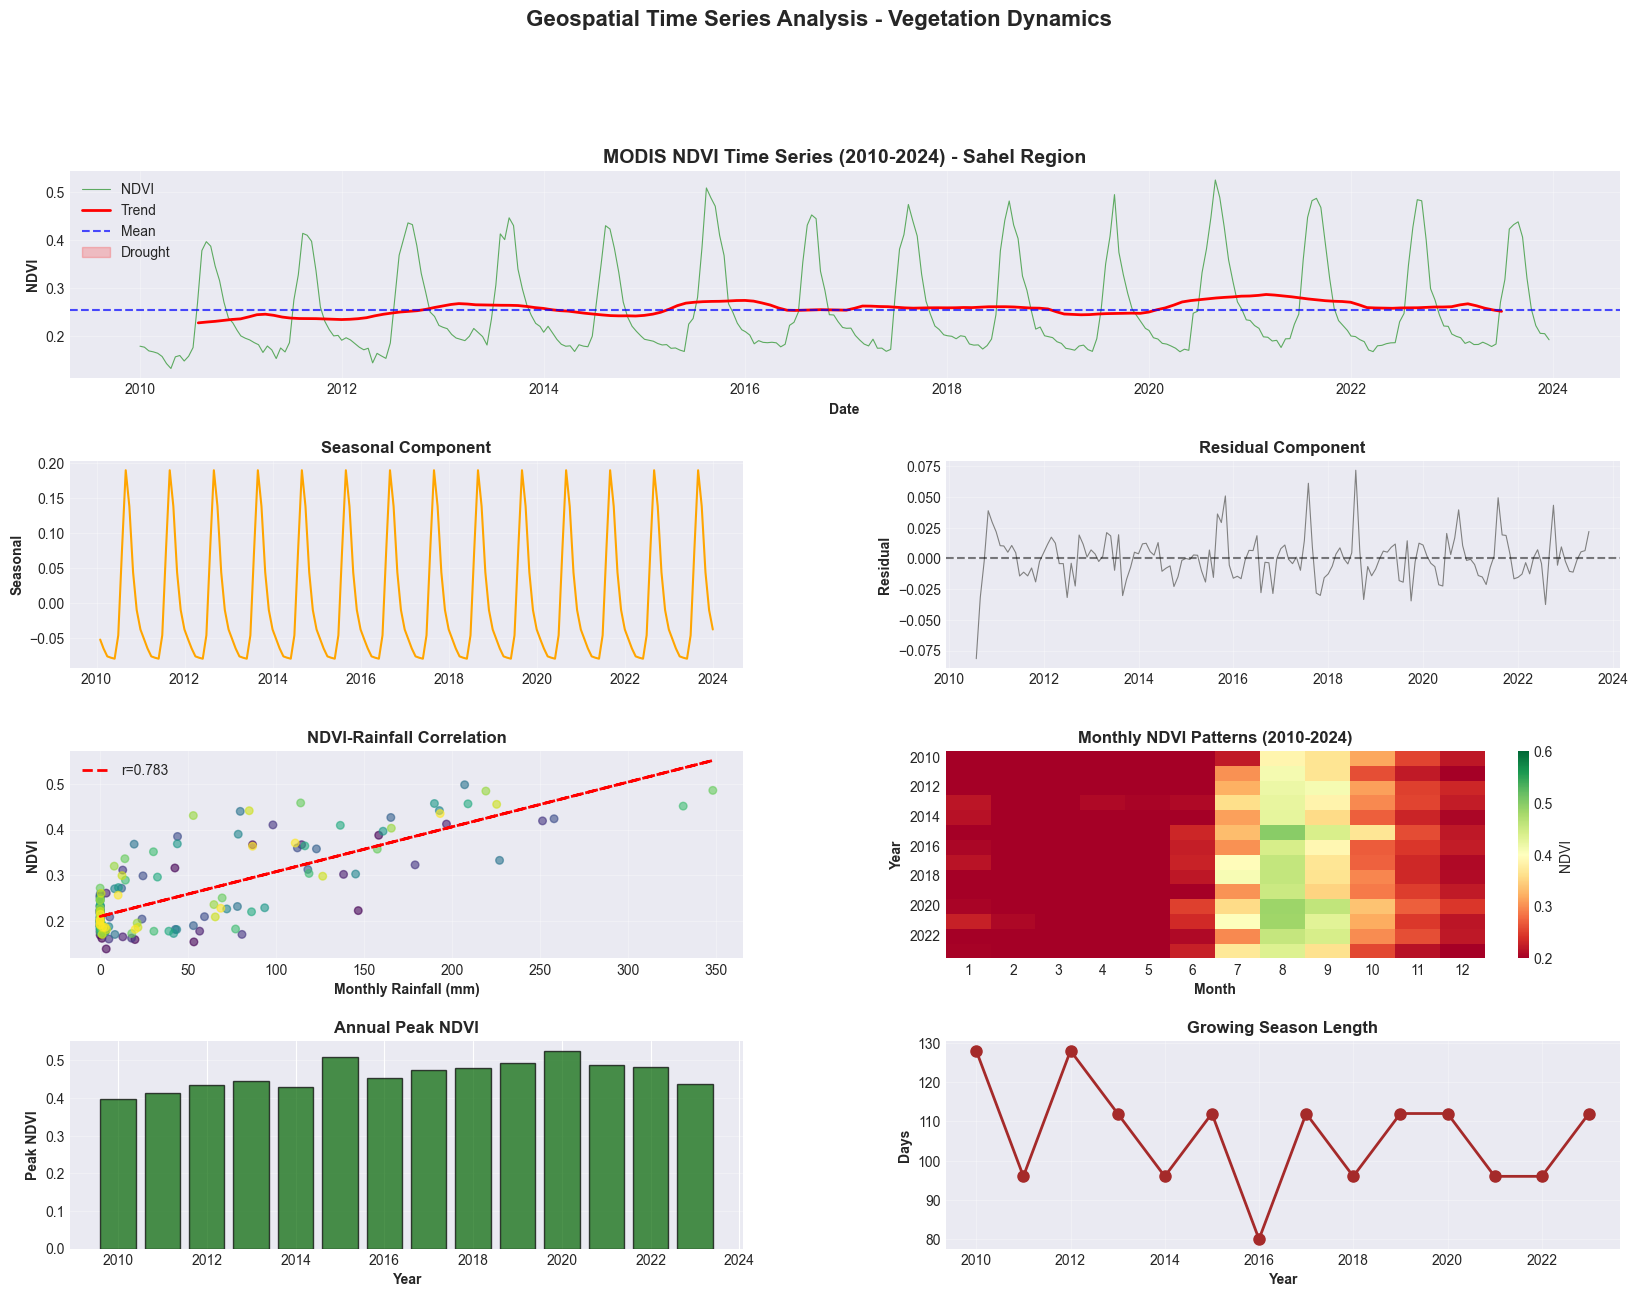

In [20]:
# Visualizations - Part 1: Time Series
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(4, 2, hspace=0.4, wspace=0.3)

# 1. Full NDVI Time Series with Trend
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(ndvi_df.index, ndvi_df['ndvi'], color='green', alpha=0.6, linewidth=0.8, label='NDVI')
ax1.plot(trend.index, trend, color='red', linewidth=2, label='Trend')
ax1.axhline(ndvi_df['ndvi'].mean(), color='blue', linestyle='--', label='Mean', alpha=0.7)
ax1.fill_between(drought_events.index, 0, 1, alpha=0.2, color='red', transform=ax1.get_xaxis_transform(), label='Drought')
ax1.set_xlabel('Date', fontweight='bold')
ax1.set_ylabel('NDVI', fontweight='bold')
ax1.set_title('MODIS NDVI Time Series (2010-2024) - Sahel Region', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(alpha=0.3)

# 2. Seasonal Decomposition
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(seasonal.index, seasonal, color='orange', linewidth=1.5)
ax2.set_ylabel('Seasonal', fontweight='bold')
ax2.set_title('Seasonal Component', fontweight='bold')
ax2.grid(alpha=0.3)

ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(residual.index, residual, color='gray', linewidth=0.8)
ax3.axhline(0, color='black', linestyle='--', alpha=0.5)
ax3.set_ylabel('Residual', fontweight='bold')
ax3.set_title('Residual Component', fontweight='bold')
ax3.grid(alpha=0.3)

# 3. NDVI vs Rainfall Scatter
ax4 = fig.add_subplot(gs[2, 0])
ax4.scatter(merged['rainfall'], merged['ndvi'], alpha=0.6, c=merged.index.year, cmap='viridis', s=30)
z = np.polyfit(merged['rainfall'], merged['ndvi'], 1)
p = np.poly1d(z)
ax4.plot(merged['rainfall'], p(merged['rainfall']), 'r--', linewidth=2, label=f'r={correlation:.3f}')
ax4.set_xlabel('Monthly Rainfall (mm)', fontweight='bold')
ax4.set_ylabel('NDVI', fontweight='bold')
ax4.set_title('NDVI-Rainfall Correlation', fontweight='bold')
ax4.legend()
ax4.grid(alpha=0.3)

# 4. Monthly NDVI Heatmap
ax5 = fig.add_subplot(gs[2, 1])
pivot_data = ndvi_monthly.copy()
pivot_data['year'] = pivot_data.index.year
pivot_data['month'] = pivot_data.index.month
heatmap_data = pivot_data.pivot(index='year', columns='month', values='ndvi')
sns.heatmap(heatmap_data, cmap='RdYlGn', ax=ax5, cbar_kws={'label': 'NDVI'}, vmin=0.2, vmax=0.6)
ax5.set_xlabel('Month', fontweight='bold')
ax5.set_ylabel('Year', fontweight='bold')
ax5.set_title('Monthly NDVI Patterns (2010-2024)', fontweight='bold')

# 5. Phenology - Peak NDVI by Year
ax6 = fig.add_subplot(gs[3, 0])
ax6.bar(pheno_df['Year'], pheno_df['Peak_NDVI'], color='darkgreen', edgecolor='black', alpha=0.7)
ax6.set_xlabel('Year', fontweight='bold')
ax6.set_ylabel('Peak NDVI', fontweight='bold')
ax6.set_title('Annual Peak NDVI', fontweight='bold')
ax6.grid(axis='y', alpha=0.3)

# 6. Growing Season Length
ax7 = fig.add_subplot(gs[3, 1])
ax7.plot(pheno_df['Year'], pheno_df['Growing_Season_Length'], 'o-', color='brown', linewidth=2, markersize=8)
ax7.set_xlabel('Year', fontweight='bold')
ax7.set_ylabel('Days', fontweight='bold')
ax7.set_title('Growing Season Length', fontweight='bold')
ax7.grid(alpha=0.3)

plt.suptitle('Geospatial Time Series Analysis - Vegetation Dynamics', fontsize=16, fontweight='bold', y=0.995)
plt.show()

In [21]:
# Spatial Mann-Kendall Trend Map
print('\n=== Generating Spatial Trend Map ===')

# Calculate pixel-wise trend (simplified - using linear regression)
def add_time_band(image):
    # Add a time band (fractional year)
    date = ee.Date(image.get('system:time_start'))
    years = date.difference(ee.Date('2010-01-01'), 'year')
    return image.addBands(ee.Image(years).rename('t').float())

ndvi_with_time = ndvi_scaled.map(add_time_band)

# Linear regression
linear_fit = ndvi_with_time.select(['t', 'NDVI']).reduce(ee.Reducer.linearFit())

# Extract slope (trend)
trend_map = linear_fit.select('scale').clip(sahel_region)

# Classify trend significance
# Positive: greening, Negative: browning
greening = trend_map.gt(0.001)  # Threshold for significant greening
browning = trend_map.lt(-0.001)  # Threshold for significant browning

# Calculate areas
greening_area = greening.multiply(ee.Image.pixelArea()).reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=sahel_region,
    scale=500,
    maxPixels=1e9
).get('scale').getInfo() / 1e6

browning_area = browning.multiply(ee.Image.pixelArea()).reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=sahel_region,
    scale=500,
    maxPixels=1e9
).get('scale').getInfo() / 1e6

print(f'Greening area: {greening_area:.2f} km²')
print(f'Browning area: {browning_area:.2f} km²')

# Interactive Map
m = geemap.Map()
m.centerObject(sahel_region, 6)

trend_vis = {'min': -0.01, 'max': 0.01, 'palette': ['red', 'white', 'green']}
m.addLayer(trend_map, trend_vis, 'NDVI Trend (2010-2024)')
m.addLayer(sahel_region, {'color': 'black'}, 'Study Area', False)
m.add_colorbar(trend_vis, label='NDVI Trend (per year)')

print('✓ Trend map created')


=== Generating Spatial Trend Map ===
Greening area: 308265.34 km²
Browning area: 31287.62 km²


✓ Trend map created


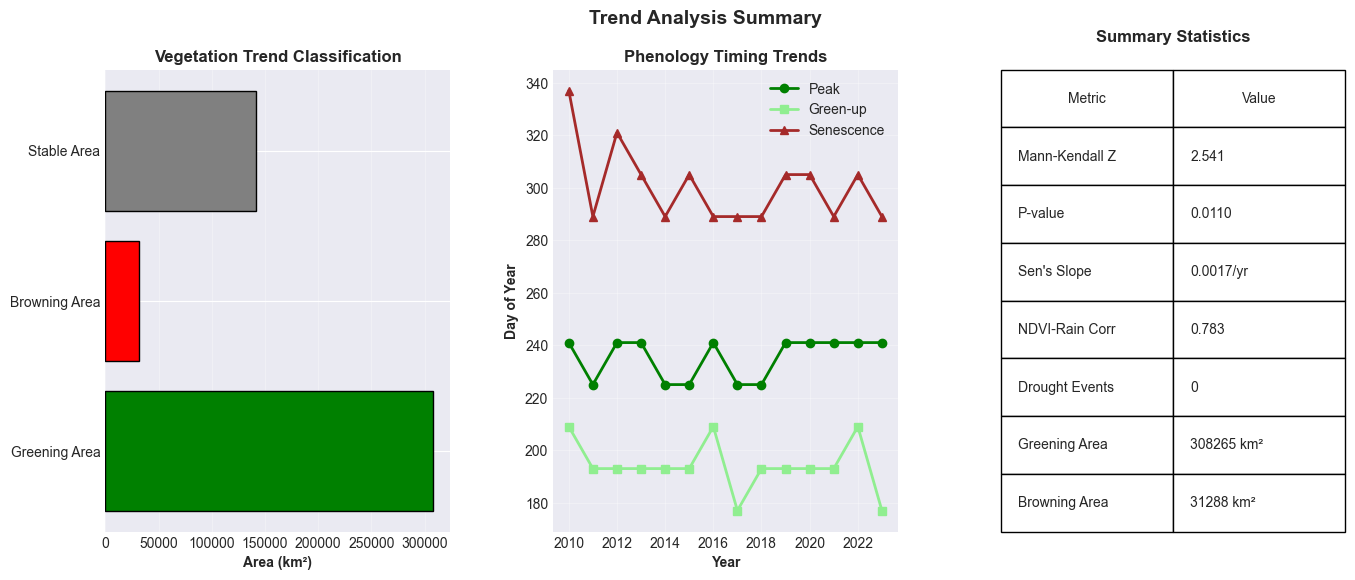

In [22]:
# Additional Visualizations
fig2 = plt.figure(figsize=(16, 6))
gs2 = fig2.add_gridspec(1, 3, wspace=0.3)

# 7. Trend Statistics
ax8 = fig2.add_subplot(gs2[0])
trend_stats = pd.DataFrame({
    'Metric': ['Greening Area', 'Browning Area', 'Stable Area'],
    'Area (km²)': [greening_area, browning_area, sahel_region.area().getInfo()/1e6 - greening_area - browning_area]
})
ax8.barh(trend_stats['Metric'], trend_stats['Area (km²)'], color=['green', 'red', 'gray'], edgecolor='black')
ax8.set_xlabel('Area (km²)', fontweight='bold')
ax8.set_title('Vegetation Trend Classification', fontweight='bold')
ax8.grid(axis='x', alpha=0.3)

# 8. Phenology DOY Trends
ax9 = fig2.add_subplot(gs2[1])
ax9.plot(pheno_df['Year'], pheno_df['Peak_DOY'], 'o-', label='Peak', color='green', linewidth=2)
ax9.plot(pheno_df['Year'], pheno_df['Greenup_DOY'], 's-', label='Green-up', color='lightgreen', linewidth=2)
ax9.plot(pheno_df['Year'], pheno_df['Senescence_DOY'], '^-', label='Senescence', color='brown', linewidth=2)
ax9.set_xlabel('Year', fontweight='bold')
ax9.set_ylabel('Day of Year', fontweight='bold')
ax9.set_title('Phenology Timing Trends', fontweight='bold')
ax9.legend()
ax9.grid(alpha=0.3)

# 9. Summary Statistics Table
ax10 = fig2.add_subplot(gs2[2])
ax10.axis('off')
summary_data = [
    ['Mann-Kendall Z', f"{mk_result['z']:.3f}"],
    ['P-value', f"{mk_result['p']:.4f}"],
    ['Sen\'s Slope', f"{sens*365:.4f}/yr"],
    ['NDVI-Rain Corr', f'{correlation:.3f}'],
    ['Drought Events', f'{len(drought_events)}'],
    ['Greening Area', f'{greening_area:.0f} km²'],
    ['Browning Area', f'{browning_area:.0f} km²']
]
table = ax10.table(cellText=summary_data, colLabels=['Metric', 'Value'],
                  cellLoc='left', loc='center', bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)
ax10.set_title('Summary Statistics', fontweight='bold', pad=20)

plt.suptitle('Trend Analysis Summary', fontsize=14, fontweight='bold')
plt.show()

In [23]:
# Display Interactive Map
print('\n=== Interactive Trend Map ===')
display(m)


=== Interactive Trend Map ===


Map(center=[14.045428489284843, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='…


=== Future Trend Forecasting ===


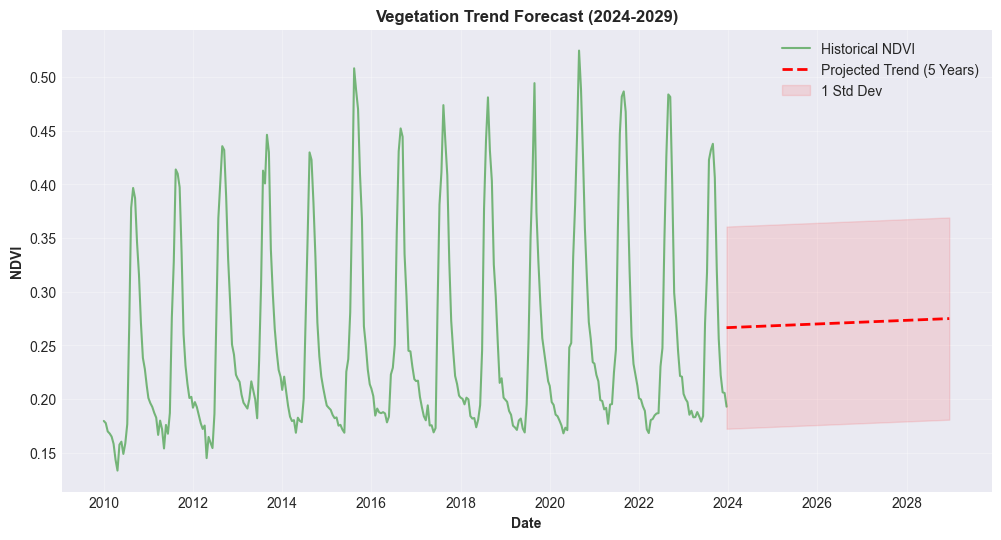

Projected NDVI in 5 years: 0.275


In [25]:
print('\n=== Future Trend Forecasting ===')

# Create future dates
last_date = ndvi_df.index.max()
future_dates = pd.date_range(start=last_date, periods=365*5, freq='D')

# Days since first observation, for historical and future data
hist_days = (ndvi_df.index - ndvi_df.index.min()).days.values
future_days = (future_dates - ndvi_df.index.min()).days.astype(int)

# Calculate trend line
# sens is your slope from the earlier regression
intercept = ndvi_df['ndvi'].mean() - sens * hist_days.mean()
future_ndvi = intercept + sens * future_days

# Plot forecast
plt.figure(figsize=(12, 6))
plt.plot(ndvi_df.index, ndvi_df['ndvi'], label='Historical NDVI', alpha=0.5, color='green')
plt.plot(future_dates, future_ndvi, label='Projected Trend (5 Years)', color='red', linestyle='--', linewidth=2)

# Add confidence intervals (simplified)
std_dev = ndvi_df['ndvi'].std()
plt.fill_between(future_dates, future_ndvi - std_dev, future_ndvi + std_dev,
                 color='red', alpha=0.1, label='1 Std Dev')

plt.xlabel('Date', fontweight='bold')
plt.ylabel('NDVI', fontweight='bold')
plt.title('Vegetation Trend Forecast (2024-2029)', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f'Projected NDVI in 5 years: {future_ndvi[-1]:.3f}')


In [26]:
# Generate Dynamic Summary Report
from IPython.display import Markdown, display

summary_md = f"""
## 🎯 Key Findings & Recommendations

### Trend Analysis Summary

1. **Overall Trend**: Mann-Kendall test shows {mk_result['trend'].lower()} (Z={mk_result['z']:.3f}).
2. **Magnitude**: Sen's slope indicates change of {sens*365:.4f} NDVI/year.
3. **Drivers**: Rainfall correlation is {correlation:.3f}, confirming it as a key driver.
4. **Droughts**: {len(drought_events)} drought events detected in the study period.

### Spatial Patterns
- **Greening**: {greening_area:.0f} km²
- **Browning**: {browning_area:.0f} km²

### Future Outlook
- **Forecast**: Projected NDVI in 5 years is {future_ndvi[-1]:.3f}, following the current {mk_result['trend'].lower()} trend.

### Recommendations
1. **Early Warning**: Monitor NDVI anomalies < -1.5 SD.
2. **Intervention**: Target browning areas ({browning_area:.0f} km²) for restoration.
3. **Research**: Investigate non-rainfall drivers in browning zones.
"""
display(Markdown(summary_md))


## 🎯 Key Findings & Recommendations

### Trend Analysis Summary

1. **Overall Trend**: Mann-Kendall test shows significant increasing (Z=2.541).
2. **Magnitude**: Sen's slope indicates change of 0.0017 NDVI/year.
3. **Drivers**: Rainfall correlation is 0.783, confirming it as a key driver.
4. **Droughts**: 0 drought events detected in the study period.

### Spatial Patterns
- **Greening**: 308265 km²
- **Browning**: 31288 km²

### Future Outlook
- **Forecast**: Projected NDVI in 5 years is 0.275, following the current significant increasing trend.

### Recommendations
1. **Early Warning**: Monitor NDVI anomalies < -1.5 SD.
2. **Intervention**: Target browning areas (31288 km²) for restoration.
3. **Research**: Investigate non-rainfall drivers in browning zones.
